# Lab 4

# Q2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, beta, lognorm

rng = np.random.default_rng(0)

def ecdf(x):
    x = np.sort(x)
    return x, np.arange(1, len(x) + 1) / len(x)


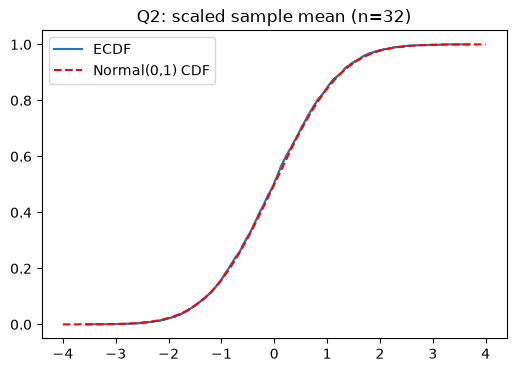

In [2]:
n, b = 32, 5_000
data = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))
stat = data.mean(axis=1) * np.sqrt(n)

x, y = ecdf(stat)
grid = np.linspace(-4, 4, 400)

plt.figure(figsize=(6, 4))
plt.step(x, y, label="ECDF")
plt.plot(grid, norm.cdf(grid, loc=0, scale=1), "r--", label="Normal(0,1) CDF")
plt.title("Q2: scaled sample mean (n=32)")
plt.legend()
plt.show()


Answer: As n increases, the scaled sample mean approaches a normal distrubution. 

# Q4

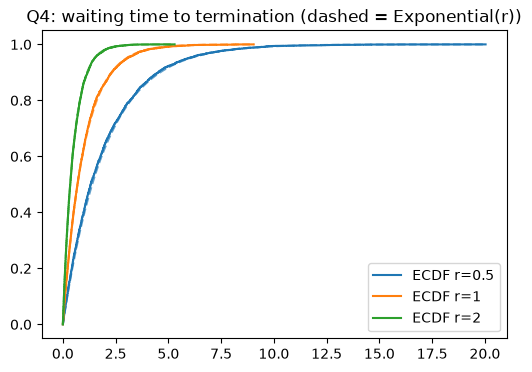

In [5]:
n_sim, dt = 5_000, 1e-3
plt.figure(figsize=(6, 4))

for r, c in [(0.5, "C0"), (1, "C1"), (2, "C2")]:
    periods = rng.geometric(r * dt, size=n_sim)  
    t = periods * dt
    x, y = ecdf(t)
    plt.step(x, y, color=c, label=f"ECDF r={r}")
    g = np.linspace(0, x.max(), 400)
    plt.plot(g, expon.cdf(g, scale=1 / r), "--", color=c, alpha=0.7)

plt.title("Q4: waiting time to termination (dashed = Exponential(r))")
plt.legend()
plt.show()


As dt goes to 0, the distribution approaches an Exponential distribution. Increasing r shifts the distribution closer to 0 since the formula is 1/r.

# Q5

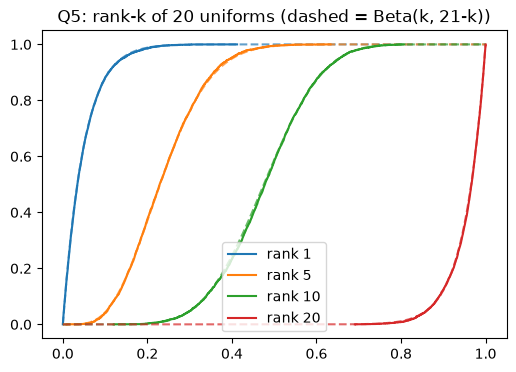

In [6]:
K, n_rep = 20, 5_000
u = np.sort(rng.uniform(size=(n_rep, K)), axis=1)  

plt.figure(figsize=(6, 4))
g = np.linspace(0, 1, 400)
for k, c in [(1, "C0"), (5, "C1"), (10, "C2"), (20, "C3")]:
    x, y = ecdf(u[:, k - 1])
    plt.step(x, y, color=c, label=f"rank {k}")
    plt.plot(g, beta.cdf(g, k, K - k + 1), "--", color=c, alpha=0.7)

plt.title("Q5: rank-k of 20 uniforms (dashed = Beta(k, 21-k))")
plt.legend()
plt.show()


This looks like a beta distribution. The distribution depends on the rank because the rank tells us where in [0,1] that value is. Low ranks are near 0 and high ranks are near 1. 

# Q6

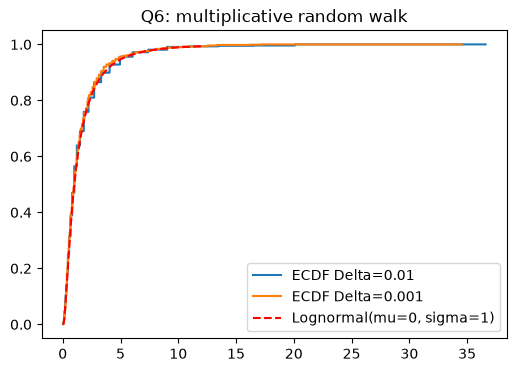

In [7]:
B = 1_000
plt.figure(figsize=(6, 4))

for delta, c in [(1/100, "C0"), (1/1000, "C1")]:
    N = int(round(1 / delta))
    ups = rng.binomial(N, 0.5, size=B)  
    log_final = np.sqrt(delta) * (ups - (N - ups))
    final = np.exp(log_final)
    x, y = ecdf(final)
    plt.step(x, y, color=c, label=f"ECDF Delta={delta:g}")

g = np.linspace(0.01, 12, 400)
plt.plot(g, lognorm.cdf(g, s=1, scale=np.exp(0)), "r--", label="Lognormal(mu=0, sigma=1)")
plt.title("Q6: multiplicative random walk")
plt.legend()
plt.show()


As delta gets closer to 0, this graph approaches a lognormal distribution.